# Hymod Sensitivitiy Analysis workflow
This notebook uses the outputs from the Hymod Sensitivity Analysis workflow to carry out a global sensitivity analysis. The model source code can be found here: https://github.com/SAFEtoolbox/SAFE-on-DAFNI. The purpose of this excersise is to quantify the output uncertainty and sensitivity by investigating the propgration of uncertainties and analysising the input-output dataset. 

The first stage of the sensitivity analysis (where we propagate the input uncertainties through the model) has been conducted using the parameter sweep. The model input parameters have been sampled 200 times between realistic bounds. Note that the input bounds and number of model runs can be edited to suit the users needs by manipulating the parameter sets within the workflow. 

The inputs that we have sampled in this example represent the 5 model parameters used to translate timeseries of meterological forcings (rainfall and temperature) to timeseries of river flows. These parameters are listed in orange below.

<left><img src="Hymod_fig.png" width="700px">

In this example the model has been applied to the Leaf catchment in the USA, for which we have daily observations of rainfall (R), potential evaporation (PE) and river flow (Q).

The two model outputs which we are interested in are (1) the mean flow and (2) the max flow. 

The second stage of the sensitivity analysis is carried out in this notebook. The following code will take you through the process of quantifying the uncertainty and sensitivity in the model outputs listed above. 

In [42]:
# Import libraries needed for analysis
import os 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import glob

In this example we use the SAFE toolbox to carry out the sensitivity analysis, we use the PAWN method. For more information see: https://safetoolbox.github.io/

In [43]:
## Install the SAFE Toolbox 
# https://safetoolbox.github.io/ 
!pip install safepython
import safepython

In [44]:
## Import scripts from the SAFE Toolbox 
from __future__ import division, absolute_import, print_function

import sys
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatRangeSlider, IntRangeSlider
import scipy.stats as st
import warnings
warnings.filterwarnings('ignore') # to hide warning messages
# Module to perform PAWN:
import safepython.PAWN as PAWN
# Module to visualize the results:
import safepython.plot_functions as pf
# Module to execute the model
from safepython.model_execution import model_execution
# Functions to perform the input sampling
from safepython.sampling import AAT_sampling, AAT_sampling_extend
# Function to calculate RMSE:
from safepython.util import aggregate_boot, RMSE
# Module that simulates the HyMod model:
from safepython import HyMod

In [45]:
# Check working directory is same folder which contains data
os.getcwd()

'/home/jovyan/data/12329621-eeb0-4982-95f4-5ed3a31236ef'

**Load and plot data**

In [46]:
# Read in observed data - this needs to be manually uploaded to the visualisation but can be downloaded as a dataset from DAFNI (Leaf Catchment Data, ID: d30c0e82-9b0f-4708-aa89-2841ce93a71c)
# Load data (one year of daily observations of rainfall, potential evaporation and flow):
data = np.genfromtxt('LeafCatch.txt', comments='%')
rain = data[0:365, 0] # select the first year of data
evap = data[0:365, 1]
flow = data[0:365, 2]
warmup = 30 # Model warmup period (days)

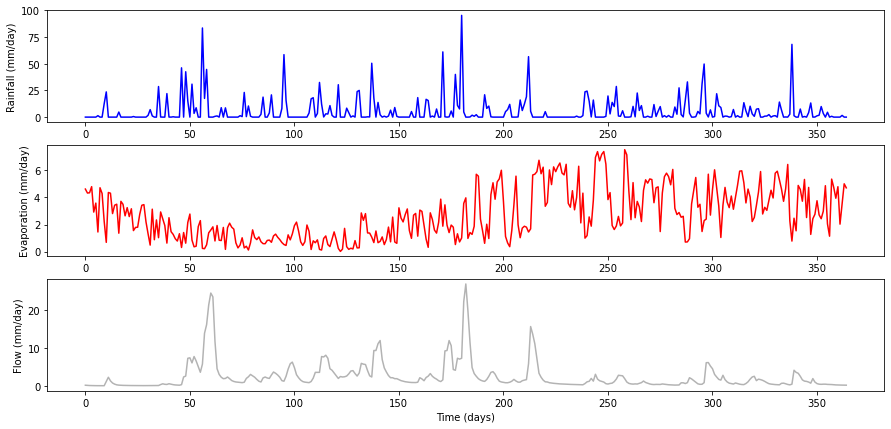

In [47]:
# Plot observed data:
plt.figure(figsize=[15,7])
plt.subplot(311); plt.plot(rain, color = 'blue'); plt.ylabel('Rainfall (mm/day)')
plt.subplot(312); plt.plot(evap, color = 'red'); plt.ylabel('Evaporation (mm/day)')
plt.subplot(313); plt.plot(flow, color=[0.7, 0.7, 0.7]); plt.ylabel('Flow (mm/day)')
plt.xlabel('Time (days)')
plt.show()

We first need to read in the output files from the parameter sweep. For this model we have 2 types of file, the first begins with 'params_' and contains the parameter values used for that unique simulation. The second begins with 'output_' and contains the flow output.

In [48]:
directory = "./"
file_paths_params = glob.glob(os.path.join(directory, "params*"))
file_paths_outputs = glob.glob(os.path.join(directory, "output*"))

In [68]:
from safepython.HyMod import hymod_sim
param = pd.read_csv('params_100906.csv', header = None)
print(param)
flow_sim, _, _ = hymod_sim(param.iloc[:,0], rain, evap)
print(flow_sim)

            0
0  284.810214
1    0.195348
2    1.050550
3    0.099214
4    0.580550
[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00 -5.67040427e-05 -1.20056065e-03
  1.24267184e-03  4.90640708e-02  6.08614165e-02  5.06593312e-02
  3.51357723e-02  2.12675370e-02  1.20818649e-02  3.09750025e-02
  3.40314299e-02  2.72412586e-02  1.84902539e-02  1.12990836e-02
  6.30599590e-03  3.27945058e-03  4.49171077e-03  4.31190752e-03
  3.22985862e-03  2.05929889e-03  1.15018790e-03  3.36470848e-04
 -9.34602672e-04  7.53774817e-03  4.81307244e-02  6.36944903e-02
  5.05536532e-02  3.50097937e-02  2.08976524e-01  2.48849448e-01
  1.98977106e-01  1.36023821e-01  3.23610672e-01  3.49756557e-01
  2.78415792e-01  1.93318001e-01  1.21476739e-01  5.45243775e-02
  2.38780802e-02  6.43320160e-01  7.95172753e-01  1.64340005e+00
  2.15466515e+00  1.90299912e+00  2.46142631e+00  2.40105550e+00
  2.24

Since the parameter sweep outputs individual fields for each model simulation we now want to combine them into input and output datasets. 

In [57]:
# Make empty dataframe to recieve the parameter sets
params_output = pd.DataFrame()

for x, file in enumerate(file_paths_params): 
    params_output = params_output.append(pd.read_csv(file, header = None).iloc[:,0])

params_output.columns = ['Sm', 'beta', 'alfa', 'Rs', 'Rf']
    
    
flow_output = pd.DataFrame()

for x, file in enumerate(file_paths_outputs): 
    flow_output[x] = pd.read_csv(file, header = None).iloc[:,0]
    
#print(flow_output)
print(params_output)

            Sm      beta      alfa        Rs        Rf
0   284.810214  0.195348  1.050550  0.099214  0.580550
0   127.183938  0.595756  1.903970  0.020217  0.641790
0   384.978312  1.183683  0.762306  0.317984  0.644318
0    47.791252  1.991529  0.974944  0.033424  0.826236
0   234.577265  0.707277  0.083284  0.370150  0.573111
..         ...       ...       ...       ...       ...
0   145.267897  1.737243  0.321871  0.535330  0.789424
0    68.775905  0.880453  1.019438  0.615706  0.440607
0   126.189133  0.091923  1.652274  0.180514  0.151672
0   326.641853  1.245256  1.655319  0.599969  0.467034
0   292.725620  1.078167  1.391120  0.814819  0.885269

[200 rows x 5 columns]


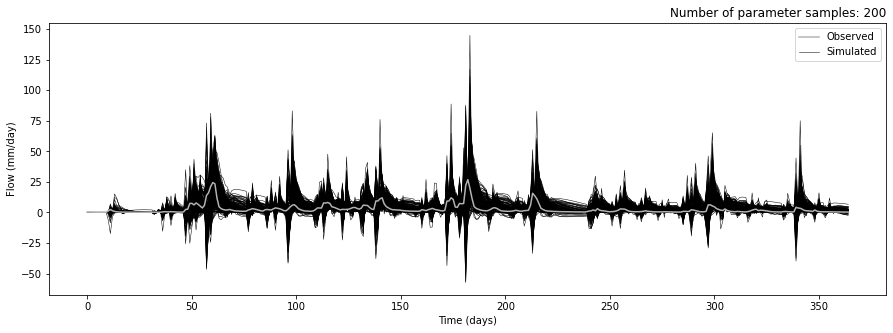

In [51]:
## Collate flow results 
QQ= flow_output.T.to_numpy()


# Plot Monte Carlo (MC) simulations results and compare with data:
plt.figure(figsize=[15,5])
plt.plot(flow, color=[0.7, 0.7, 0.7]) # plot for legend
plt.plot(np.transpose(QQ), 'k', linewidth = 0.5)
plt.plot(flow, color=[0.7, 0.7, 0.7])
plt.ylabel('Flow (mm/day)'); plt.xlabel('Time (days)')
plt.legend(['Observed', 'Simulated'])
plt.title("Number of parameter samples: 200", loc='right')
plt.show()

Initially, it is often useful to plot the input-output dataset to get a visual idea of the relationships between inputs and outputs. 

In [52]:
# Calculate MAX and MEAN for each parameter sample:
YY = np.nan * np.ones((200, 2))
YY[:, 0] = QQ[:, warmup:365].max(axis = 1)
YY[:, 1] =  QQ[:, warmup:365].mean(axis = 1)

X_Labels = ['Sm', 'beta', 'alfa', 'Rs', 'Rf'] # Names of input parameters
M = len(X_Labels) # Number of parameters

# Define interactive visualisation function to produce scatter plots for the chosen output metrics:
def scatter_function(metric='MAX'):
    if metric == 'MAX':
        i = 0
    elif metric == 'MEAN':
        i = 1
            
    # Extract output metric:
    Y = YY[:, i]; 
    Y_Label = metric + '(mm/day)'

    # Scatter plots of the output metric against input samples:
    plt.figure(figsize=[15,3])
    pf.scatter_plots(params_output.to_numpy(), Y, Y_Label=Y_Label, X_Labels=X_Labels)
    plt.title("Number of parameter samples:200", loc='right')
    plt.show()
    
interact(scatter_function, metric = ['MAX','MEAN']);

interactive(children=(Dropdown(description='metric', options=('MAX', 'MEAN'), value='MAX'), Output()), _dom_cl…

Visually, the inputs with the strongest output relationships appear to change depending on which metric we are looking at. For the max flow, Rf has the most obvious visual relationship, but for mean this is Beta and Sm. 

We will now quantify these relationships by using the PAWN method to calculate sensitivity indicies. These metrics describe how much each input is contributing to the output uncertainty. The higher the metric, the more this input is having an influence on the output. 

In [53]:
# Define interactive visualisation function to calculate and visualise sensitivity indices
# for the chosen output metric and different choices of the PAWN tuning parameters (n,Nboot,aggr)

def pawn_function(metric='MAX', n = 5, aggr = 'median',Nboot = 500):
    # Extract output metric:
    if metric == 'MAX':
        i = 0
    elif metric == 'MEAN':
        i = 1   
    Y = YY[:, i]; 
    
    # Apply PAWN
    # Tuning parameters:
    # n = number of conditioning intervals
    # aggr = statistic to aggregate KS values
    # Nboot = number of bootstrapping resamples used to derive confidence bounds of sensitivity indices   

    # Compute sensitivity indices for Nboot bootstrap resamples
    KS_median, KS_mean, KS_max = PAWN.pawn_indices(params_output.to_numpy(), Y, n, Nboot=Nboot)
    # KS_median and KS_mean and KS_max have shape (Nboot, M)
        
    # Compute mean and confidence intervals of the sensitivity indices across the bootstrap resamples:
    KS_median_m, KS_median_lb, KS_median_ub = aggregate_boot(KS_median) # shape (M,)
    KS_mean_m, KS_mean_lb, KS_mean_ub = aggregate_boot(KS_mean) # shape (M,)
    KS_max_m, KS_max_lb, KS_max_ub = aggregate_boot(KS_max) # shape (M,)

    # Plot sensitivity indices:
    plt.figure()
    plt.title("Output metric = %s" % metric)
    if aggr == 'median':
        pf.boxplot1(KS_median_m, S_lb=KS_median_lb, S_ub=KS_median_ub, X_Labels=X_Labels, Y_Label='sensitivity (median KS)')
    if aggr == 'mean':
        pf.boxplot1(KS_mean_m, S_lb=KS_mean_lb, S_ub=KS_mean_ub, X_Labels=X_Labels, Y_Label='sensitivity (mean KS)')
    if aggr == 'max':
        pf.boxplot1(KS_max_m, S_lb=KS_max_lb, S_ub=KS_max_ub, X_Labels=X_Labels, Y_Label='sensitivity (max KS)')
    plt.show()
    
interact(pawn_function, metric = ['MAX','MEAN'], n = (2, 20, 1), aggr = ['median', 'mean','max'], Nboot = (0, 500, 10));

interactive(children=(Dropdown(description='metric', options=('MAX', 'MEAN'), value='MAX'), IntSlider(value=5,…